In [1]:
from libraries import *

/opt/miniconda3/envs/py310/bin/python


In [2]:
gp.setParam("OutputFlag", 0) # Disables Gurobi logs (Affects all models created afterward)

Set parameter Username
Set parameter LicenseID to value 2769212
Academic license - for non-commercial use only - expires 2027-01-22


      Time_s  Longitude_deg  Latitude_deg   Altitude_m
0        0.0     279.000000     49.000000  25000.00000
1     1800.0     278.991146     49.029046  23678.70919
4     3600.0     278.974006     49.042329  23672.57558
7     5400.0     278.954818     49.050965  23307.62729
10    7200.0     278.932833     49.055108  22986.64633
13    9000.0     278.880577     49.044621  20913.29464
16   10800.0     278.900893     49.018890  19378.08451
19   12600.0     278.949781     48.997741  19373.21189
22   14400.0     278.989935     48.980466  20387.52864
25   16200.0     279.004618     48.984263  21367.19138
28   18000.0     279.006678     48.992932  21378.46182
31   19800.0     279.022780     49.000290  21723.81151
34   21600.0     279.038680     49.008456  21722.88519
37   23400.0     279.059257     49.017817  23222.08889
40   25200.0     279.061682     49.024487  23068.06755
43   27000.0     279.064344     49.029620  22978.23955
46   28800.0     279.067620     49.034208  22980.28988
49   30600

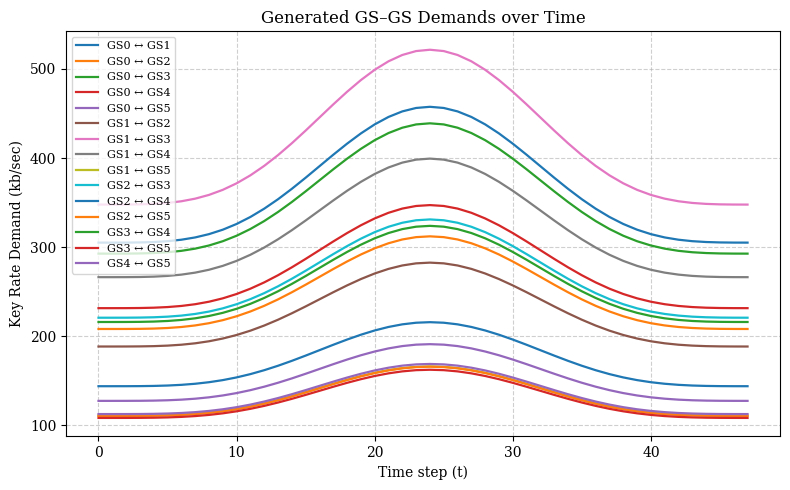

In [3]:
prob = 2
gnodes, hnodes, links, demands = init_setup_real_online(prob)
#gnodes, hnodes, links, demands = init_setup_training_online()

nodes = gnodes + hnodes

n_hnodes  = len(hnodes)
n_demands = len(demands)

In [4]:
# Initialize state and action
state  = [{} for _ in syst.T]
action = [{} for _ in syst.T]
reward = [0  for _ in syst.T]

state[0]["demands"] = demands
state[0]["a"] = {i: 0 for i in range(len(links))}

# ---------- Hyperparams ----------
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP = 0.2
LR = 1e-4 #3e-4
EPOCHS = 10
BATCH_SIZE = 128
ENTROPY_COEF_INITIAL = 0.01         # >>> CHANGE - will decay over training
ENTROPY_COEF_MIN = 0.001            # >>> CHANGE
ENTROPY_DECAY = 0.999 #0.995               # >>> CHANGE
VALUE_COEF = 0.5

# Training hyperparams
num_episodes = 4000
episode_len = len(syst.T)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

entropy_coef = ENTROPY_COEF_INITIAL  # >>> CHANGE

In [5]:

def build_state_vector_for_time(state_t, links, t, gnodes, hnodes, max_links=20, normalize=True):
    link_features = []
    total_nodes = len(gnodes) + len(hnodes)
    
    # Pre-calculate coordinate bounds for normalization (Example ranges)
    # Better yet, use the service area limits (e.g., 270-285 lon, 40-55 lat)
    LON_MIN, LON_MAX = 276.0, 285.0
    LAT_MIN, LAT_MAX = 46.0, 50.0
    ALT_MAX = 25.0

    def norm_lon(l): return (l - LON_MIN) / (LON_MAX - LON_MIN)
    def norm_lat(l): return (l - LAT_MIN) / (LAT_MAX - LAT_MIN)
    def norm_alt(a): return a / ALT_MAX

    # 1. Process Links with Geometric Context
    for idx_l in range(max_links):
        if idx_l < len(links):
            l = links[idx_l]
            
            # Key Buffer (QKP) - Log Scaled
            qkp_val = np.log10(1 + state_t.get("a", {}).get(idx_l, 0.0)) / 8.0
            
            # Current Capacity (K_MAX) - Normalized by a realistic max (e.g., 100Mbps)
            kmax_val = np.log10(1 + l.K_MAX[t]) / 6.0 
            
            # GEOMETRIC ENCODING: Position of Node 1 and Node 2
            # This is much more powerful than normalized IDs
            n1_coords = [norm_lon(l.n1.lg[t] if isinstance(l.n1, hap) else l.n1.lg),
                         norm_lat(l.n1.la[t] if isinstance(l.n1, hap) else l.n1.la)]
            
            n2_coords = [norm_lon(l.n2.lg[t] if isinstance(l.n2, hap) else l.n2.lg),
                         norm_lat(l.n2.la[t] if isinstance(l.n2, hap) else l.n2.la)]
            
            # Add features: [QKP, Capacity, Src_Lon, Src_Lat, Dst_Lon, Dst_Lat, Active]
            link_features.extend([qkp_val, kmax_val] + n1_coords + n2_coords + [1.0])
        else:
            # Padding (7 features per link now)
            link_features.extend([0.0] * 7)

    # 2. Process Demands with Geometric Pairs
    d_vec = []
    demands_list = state_t.get("demands", [])
    
    # Instead of iterating all pairs (which is O(N^2)), 
    # you might want to only encode the 'Active' demands to save space, 
    # but for a fixed-size MLP input, the GS-to-GS grid is fine.
    for src in gnodes:
        for dst in gnodes:
            if src == dst: continue
            
            matched = next((d for d in demands_list if d.n1 == src and d.n2 == dst), None)
            
            # Geometric info for the demand pair
            src_pos = [norm_lon(src.lg), norm_lat(src.la)]
            dst_pos = [norm_lon(dst.lg), norm_lat(dst.la)]
            
            if matched:
                kreq = np.log10(1 + float(matched.K_REQ[t])) / 5.0
                d_vec.extend(src_pos + dst_pos + [kreq, 1.0])
            else:
                d_vec.extend(src_pos + dst_pos + [0.0, 0.0])

    return np.concatenate([link_features, d_vec]).astype(np.float32)

def scarq_policy(state, links, t):
    """
    Adapted Heuristic: Scarcity & Contention Aware (1-hop only)
    Converts the offline logic into an online action selection for time t.
    """
    n_links = len(links)
    n_hnodes = len(hnodes)
    demands = state[t]["demands"]
    
    # 1. Initialize constraints and action
    #action = np.zeros(n_links, dtype=int)
    action_matrix = np.zeros((n_demands, len(links)), dtype=int)
    max_cnct_up = [1] * n_hnodes  # HAP TX limits (assuming 1 for this logic)
    max_cnct_dwn = [1] * n_hnodes # HAP RX limits
    
    # Current QKP bits from state (assumed stored as raw bits or decoded)
    # If state_t["a"] is log-normalized, decode it first!
    qkp_s = [state[t]["a"].get(i, 0.0) for i in range(n_links)]

    # ---------------------------------------------------------
    # Step 1: Enumerate feasible 1-hop paths per demand
    # ---------------------------------------------------------
    feasible_paths = {d: [] for d in demands}
    link_usage = [0] * n_links
    
    for d in demands:
        src, dst = d.n1, d.n2
        for idx_l1, l1 in enumerate(links):
            if l1.n1 != src: continue
            for idx_l2, l2 in enumerate(links):
                if l2.n2 != dst: continue
                
                # Check if they share a HAP (mid-point)
                if l1.n2 == l2.n1 and l1.n2 in hnodes:
                    mid = l1.n2
                    
                    fresh_ok = (l1.K_MAX[t] >= d.K_REQ[t] and 
                                l2.K_MAX[t] >= d.K_REQ[t])
                    
                    qkp_ok = (qkp_s[idx_l1] / syst.THETA >= d.K_REQ[t] and 
                              qkp_s[idx_l2] / syst.THETA >= d.K_REQ[t])
                    
                    if fresh_ok or qkp_ok:
                        feasible_paths[d].append((idx_l1, idx_l2, mid))
                        link_usage[idx_l1] += 1
                        link_usage[idx_l2] += 1

    # ---------------------------------------------------------
    # Step 2: Order demands by Scarcity
    # (Least paths first, then largest requirement)
    # ---------------------------------------------------------
    ordered_demands = sorted(
        demands,
        key=lambda d: (len(feasible_paths[d]), -d.K_REQ[t])
    )

    # ---------------------------------------------------------
    # Step 3: Greedy Allocation with Contention Awareness
    # ---------------------------------------------------------
    for d in ordered_demands:
        # Sort paths for this demand by least link contention
        paths = sorted(
            feasible_paths[d],
            key=lambda p: link_usage[p[0]] + link_usage[p[1]]
        )
        
        for idx_l1, idx_l2, mid in paths:
            mid_idx = hnodes.index(mid)
            
            # Respect HAP connection limits
            if max_cnct_up[mid_idx] == 0 or max_cnct_dwn[mid_idx] == 0:
                continue
                
            # Path selection logic
            # Priority: Can we serve it with ONLY stored bits? (No action needed)
            if (qkp_s[idx_l1] / syst.THETA >= d.K_REQ[t] and 
                qkp_s[idx_l2] / syst.THETA >= d.K_REQ[t]):
                
                # Update local tracker (bits effectively consumed)
                qkp_s[idx_l1] -= d.K_REQ[t] * syst.THETA
                qkp_s[idx_l2] -= d.K_REQ[t] * syst.THETA
                
                # Consume HAP capacity even if using QKP? 
                # (Your offline logic suggests yes to prevent multi-use)
                #max_cnct_up[mid_idx] = 0
                #max_cnct_dwn[mid_idx] = 0
                break
            
            # If we need fresh keys, we activate the links (set action to 1)
            else:
                # action[idx_l1] = 1
                # action[idx_l2] = 1
                action[demands.index(d)][idx_l1] = 1
                action[demands.index(d)][idx_l2] = 1
                max_cnct_up[mid_idx]  = 0
                max_cnct_dwn[mid_idx] = 0
                # Note: We don't update qkp_s here because fresh generation 
                # happens in the environment 'step', not the heuristic.
                break


    # --------------------------------------------------
    # Step 4: Solve optimization with heuristic action
    # --------------------------------------------------
    solution_heur, _, A_next_heur = online_new(
        gnodes,
        hnodes,
        links,
        state,
        action_matrix,
        t,
        f_qkp,
        0
    )

    # --------------------------------------------------
    # Step 5: Compute total served keys
    # --------------------------------------------------
    if "r_h" not in solution_heur:
        return 0.0, solution_heur, A_next_heur

    k_srv_heur = sum(
        solution_heur["r_h"][idx_d]
        for idx_d, _ in enumerate(demands)
    )

    return k_srv_heur, solution_heur, A_next_heur

def mcr_policy(state, links, t, n_samples=3):
    """
    Online Monte Carlo 1-hop random heuristic.
    Samples multiple random feasible allocations and keeps the best one.
    """

    n_links = len(links)
    n_hnodes = len(hnodes)
    demands = state[t]["demands"]
    n_demands = len(demands)

    best_reward = -1
    best_solution = None
    best_A_next = None

    # ------------------------------------------------------------
    # Monte Carlo sampling
    # ------------------------------------------------------------
    for _ in range(n_samples):

        # action_matrix[d, l]
        action_matrix = np.zeros((n_demands, n_links), dtype=int)

        max_cnct_up  = [1] * n_hnodes
        max_cnct_dwn = [1] * n_hnodes

        shuffled_demands = random.sample(demands, len(demands))

        # --------------------------------------------------------
        # Random feasible allocation (1-hop only)
        # --------------------------------------------------------
        for d in shuffled_demands:

            src, dst = d.n1, d.n2
            feasible_pairs = []

            for idx_l1, l1 in enumerate(links):
                if l1.n1 != src:
                    continue

                for idx_l2, l2 in enumerate(links):
                    if l2.n2 != dst:
                        continue

                    if l1.n2 == l2.n1 and l1.n2 in hnodes:
                        mid = l1.n2
                        mid_idx = hnodes.index(mid)

                        if (
                            max_cnct_up[mid_idx] > 0 and
                            max_cnct_dwn[mid_idx] > 0 and
                            l1.K_MAX[t] > 0 and
                            l2.K_MAX[t] > 0
                        ):
                            feasible_pairs.append((idx_l1, idx_l2, mid_idx))

            if feasible_pairs:
                idx_l1, idx_l2, mid_idx = random.choice(feasible_pairs)

                action_matrix[demands.index(d)][idx_l1] = 1
                action_matrix[demands.index(d)][idx_l2] = 1

                max_cnct_up[mid_idx]  = 0
                max_cnct_dwn[mid_idx] = 0

        # --------------------------------------------------------
        # Evaluate via online_new
        # --------------------------------------------------------
        solution, reward, A_next = online_new(
            gnodes,
            hnodes,
            links,
            state,
            action_matrix,
            t,
            f_qkp,
            0
        )

        if "r_h" in solution:
            total_served = sum(solution["r_h"][i] for i in range(n_demands))
        else:
            total_served = 0.0

        # Keep best sample
        if total_served > best_reward:
            best_reward = total_served
            best_solution = solution
            best_A_next = A_next

    return best_reward, best_solution, best_A_next

class ResidualBlock(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.ln = nn.LayerNorm(size)
        self.fc = nn.Linear(size, size)

    def forward(self, x):
        # Residual connection helps gradients flow back to early layers
        return x + F.silu(self.fc(self.ln(x)))

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )
        self.silu = nn.SiLU()

    def forward(self, x):
        return self.silu(x + self.net(x))

class ActorCriticCategorical(nn.Module):
    def __init__(self, state_dim, n_demands_max, n_haps, hidden=64):
        super().__init__()
        self.n_haps = n_haps
        self.n_choices = n_demands_max + 1 # Demands + Idle
        
        self.encoder = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.LayerNorm(hidden),
            nn.SiLU(),
        )
        
        # (One set of choices for RX/Uplink, one for TX/Downlink)
        self.actor_head = nn.Sequential(
            ResidualBlock(hidden),
            nn.Linear(hidden, 2 * n_haps * self.n_choices) 
        )
        
        self.critic_head = nn.Sequential(
            ResidualBlock(hidden),
            nn.Linear(hidden, 1)
        )
        
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            # Orthogonal init helps prevents early policy collapse
            nn.init.orthogonal_(m.weight, gain=0.01) 
            nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.encoder(x)
        
        # index 0: RX (Uplink), index 1: TX (Downlink)
        logits = self.actor_head(features).view(-1, 2, self.n_haps, self.n_choices)
        probs = torch.softmax(logits, dim=-1) 
        
        value = self.critic_head(features)
        return probs, value

class PPOBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.logprobs = []
        self.state_values = []
        self.rewards = []
        self.is_terminals = []
    
    def clear(self):
        del self.states[:]
        del self.actions[:]
        del self.logprobs[:]
        del self.state_values[:]
        del self.rewards[:]
        del self.is_terminals[:]

class PPOAgent:
    def __init__(self, state_dim, n_demands, n_hnodes, lr=1e-4):
        self.gamma = 0.99
        self.lam = 0.95
        self.eps_clip = 0.2
        self.K_epochs = 10
        self.n_haps = n_hnodes
        self.n_demands = n_demands
        
        self.model = ActorCriticCategorical(state_dim, n_demands, n_hnodes).to(device=DEVICE)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.MseLoss = nn.MSELoss()

    def select_action(self, state_vec):
        s = torch.tensor(state_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            probs, value = self.model(s) # [1, 2, n_haps, n_choices]
        
        dist = Categorical(probs)
        action = dist.sample() # [1, 2, n_haps]
        
        # Sum log_prob across BOTH heads and ALL HAPs
        logp = dist.log_prob(action).sum(dim=[1, 2])
        
        return action.squeeze(0).cpu().numpy(), logp.squeeze(0), value.squeeze(0)

    # ... compute_gae remains exactly the same as your previous code ...

    def update(self, states, actions, old_logps, returns, advantages, entropy_coef):
        #advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        if advantages.std() < 1e-5:
            advantages = advantages - advantages.mean()
        else:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        for _ in range(self.K_epochs):
            probs, values = self.model(states.to(DEVICE))
            dist = Categorical(probs)
            
            # logp is summed across the choices of all HAPs
            #new_logps = dist.log_prob(actions.to(DEVICE)).sum(dim=-1)
            new_logps = dist.log_prob(actions.to(DEVICE)).sum(dim=[1, 2])
            entropy = dist.entropy().sum(dim=[1, 2]).mean()
            
            ratio = torch.exp(new_logps - old_logps)
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            
            loss = -torch.min(surr1, surr2).mean() + 0.5 * self.MseLoss(values.view(-1), returns) - entropy_coef * entropy
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def compute_gae(self, rewards, values, dones):
        """
        Generalized Advantage Estimation
        rewards: [T], values: [T+1], dones: [T]
        """
        T = len(rewards)
        adv = torch.zeros(T, device=DEVICE)
        lastgaelam = 0
        for t in reversed(range(T)):
            nonterminal = 1.0 - dones[t]
            # TD Error: delta = r_t + gamma * V(s_t+1) - V(s_t)
            delta = rewards[t] + self.gamma * values[t+1] * nonterminal - values[t]
            lastgaelam = delta + self.gamma * self.lam * nonterminal * lastgaelam
            adv[t] = lastgaelam
            
        returns = adv + values[:-1]
        return adv, returns

In [6]:
def get_z_from_demand_choices(hap_picks, demands, links, hnodes):
    # Initialize z_dict with zeros
    z = {idx_d: {idx_l: 0 for idx_l in range(len(links))} for idx_d in range(len(demands))}
    
    rx_picks = hap_picks[0] # Uplink choices [n_haps]
    tx_picks = hap_picks[1] # Downlink choices [n_haps]

    # Run this once after initializing your 'links' and 'hnodes'
    UPLINK_LOOKUP = {(l.n1, l.n2): i for i, l in enumerate(links) if l.n2 in hnodes}
    DOWNLINK_LOOKUP = {(l.n1, l.n2): i for i, l in enumerate(links) if l.n1 in hnodes}

    for hap_idx, selected_hap in enumerate(hnodes):
        
        # --- Handle Uplink (RX: GS -> HAP) ---
        rx_val = rx_picks[hap_idx]
        if rx_val > 0:
            d_idx = int(rx_val - 1)
            if d_idx < len(demands):
                src_gs = demands[d_idx].n1
                # Use the pre-computed lookup
                l_idx = UPLINK_LOOKUP.get((src_gs, selected_hap))
                if l_idx is not None:
                    z[d_idx][l_idx] = 1

        # --- Handle Downlink (TX: HAP -> GS) ---
        tx_val = tx_picks[hap_idx]
        if tx_val > 0:
            d_idx = int(tx_val - 1)
            if d_idx < len(demands):
                dst_gs = demands[d_idx].n2
                # Use the pre-computed lookup
                l_idx = DOWNLINK_LOOKUP.get((selected_hap, dst_gs))
                if l_idx is not None:
                    z[d_idx][l_idx] = 1
                        
    return z

## Training Loop

Episode 1/4000, total reward: -42.460, entropy_coef: 0.0100, demands: 3, mean_kbps_rand: 5.3670192705113084, ratio_heur=0.0008702988127078123 ratio=4, k_srv=236509, k_req=5706890
Episode 2/4000, total reward: -44.913, entropy_coef: 0.0100, demands: 3, mean_kbps_rand: 9.084068861921326, ratio_heur=0.0009746641786482145 ratio=1, k_srv=138121, k_req=11018256
Episode 3/4000, total reward: -45.383, entropy_coef: 0.0100, demands: 3, mean_kbps_rand: 6.088732389220579, ratio_heur=0.0008298056952248901 ratio=0, k_srv=45584, k_req=7287127
Episode 4/4000, total reward: -47.310, entropy_coef: 0.0100, demands: 3, mean_kbps_rand: 2.734990898034545, ratio_heur=0.0009746487895821478 ratio=1, k_srv=38505, k_req=3379576
Episode 5/4000, total reward: -45.141, entropy_coef: 0.0100, demands: 3, mean_kbps_rand: 6.184429270524393, ratio_heur=0.0007891650235722333 ratio=1, k_srv=108066, k_req=7213320
Episode 6/4000, total reward: -45.979, entropy_coef: 0.0099, demands: 3, mean_kbps_rand: 5.479333094044948, ra

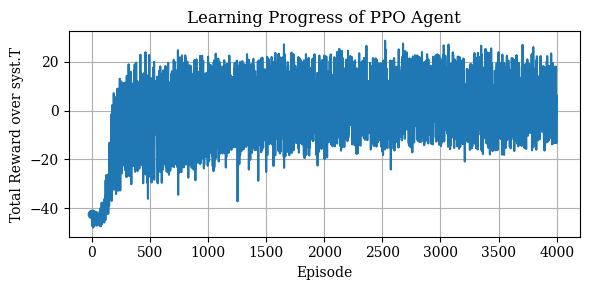

In [7]:
f_qkp = 1

# prepare agent
n_links = len(links)
n_demands = len(demands)   # assume constant across T

# choose state_dim produced by build_state_vector_for_time
state_vector_example = build_state_vector_for_time(state[0], links, 0, gnodes, hnodes)
state_dim = len(state_vector_example)

agent = PPOAgent(state_dim, n_demands, n_hnodes, lr=LR)

# Track total rewards per episode
episode_rewards = []

if f_qkp:
    solution = {"a": state[0]["a"].copy()}
else:
    solution = {}

#WARM_EPISODES  = 500
DECAY_EPISODES = 300
k = 1

for ep in range(num_episodes):
    # reset state & action containers
    state = [{} for _ in syst.T]
    action = [{} for _ in syst.T]

    if f_qkp:
        state[0]["a"] = {i: 0 for i in range(n_links)}

    # rollout buffers
    states_buf = []
    actions_buf = []
    logps_buf = []
    rewards_buf = []
    dones_buf = []
    values_buf = []

    total_reward = 0.0

    # Calculate a 'progress' factor from 0.0 to 1.0
    progress = ep / num_episodes
    
    # Start with a max of 50 kbps, end with 1000 kbps
    max_now = 10 + (990 * progress) 
    
    # Still use randomness, but within an ever-expanding "boundary"
    mean_kbps_rand = random.uniform(1, max_now)

    #mean_kbps_rand = random.randint(1, 1 + int(10 * ep/num_episodes))
    #mean_kbps_rand = random.randint(1, 1000)
    k_req_vals = [mean_kbps_rand] * len(syst.T) # 25600 bits/sec
    demands_space = []
    demands_space = generate_demands(gnodes, syst, mean_kbps=0.01*mean_kbps_rand, amp=0.5, noise_std=0.0, pattern="stadium")

    MIN_DEMANDS = 1
    MAX_DEMANDS = len(demands_space)

    # Before the for t in syst.T: loop
    if ep < num_episodes / 10:
        k = 1  # Only 1 demand: let the agent learn basic RX/TX pairing first
    elif ep < 2 * num_episodes / 10:
        k = random.randint(1, 2) # Slightly more complex
    else:
        k = random.randint(MIN_DEMANDS, MAX_DEMANDS) # Full complexity

    ################
    k=3
    ################
    demands = random.sample(demands_space, k)
    random.shuffle(demands)

    state[0]["demands"] = demands.copy()

    k_srv = 0
    k_req = 0

    for t in syst.T:
        # >>> NEW — build action mask before selecting action
        s_vec = build_state_vector_for_time(state[t], links, t, gnodes, hnodes)
        
        # Inside the for t in syst.T: loop
        hap_choices, logp, value = agent.select_action(s_vec) 
        
        # 2. Convert to the dictionary format for Gurobi
        z_dict = get_z_from_demand_choices(hap_choices, demands, links, hnodes)

        #print(z_dict)

        # call your environment / model
        # Maximum Tx/Rx Connection
        check_tx, check_rx = 1, 1
        sum_tx, sum_rx = {}, {}

        nodes = gnodes + hnodes

        k_srv_heur1, k_srv_heur2 = -math.inf, -math.inf
        k_srv_heur1, _, _ = scarq_policy(state, links, t)
        k_srv_heur2, _, _ = mcr_policy(state, links, t)
        
        k_srv_heur = max(k_srv_heur1, k_srv_heur2)

        solution, reward_t, A_next = online_new(gnodes, hnodes, links, state, z_dict, t, f_qkp, k_srv_heur)

        reward[t] = reward_t
        total_reward += reward_t

        k_srv += sum(solution["r_h"][idx_d] * syst.THETA for idx_d, d in enumerate(state[t]["demands"]))
        k_req += sum(d.K_REQ[t] * syst.THETA for idx_d, d in enumerate(state[t]["demands"]))

        # store rollout data
        states_buf.append(torch.tensor(s_vec, dtype=torch.float32))
        # Ensure hap_choices is converted to a tensor for the buffer
        # Shape: [2, n_haps]
        actions_buf.append(torch.tensor(hap_choices, dtype=torch.long, device=DEVICE))
        logps_buf.append(logp)
        values_buf.append(value)
        rewards_buf.append(torch.tensor(float(reward_t), dtype=torch.float32))
        dones_buf.append(torch.tensor(0.0))

        # step to next state
        if t + 1 < episode_len:
            if f_qkp:
                if check_tx and check_rx:
                    state[t+1]["a"] = A_next
                else:
                    state[t+1]["a"] = state[t]["a"]
            state[t+1]["demands"] = state[t]["demands"]

    # bootstrap final value
    final_s_vec = build_state_vector_for_time(state[-1], links, t, gnodes, hnodes)
    with torch.no_grad():
        _, final_value = agent.model(torch.tensor(final_s_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0))
    values_tensor = torch.stack(values_buf).to(DEVICE)
    values_tensor = torch.cat([values_tensor.view(-1), final_value.view(-1)])  # Now shape is [T+1]

    rewards_tensor = torch.stack(rewards_buf).to(DEVICE)
    dones_tensor = torch.stack(dones_buf).to(DEVICE)

    advantages, returns = agent.compute_gae(rewards_tensor, values_tensor, dones_tensor)

    # prepare PPO update batches
    states_b = torch.stack(states_buf)
    actions_b = torch.stack(actions_buf)
    old_logps_b = torch.stack(logps_buf).to(DEVICE)
    returns_b = returns.detach()
    adv_b = advantages.detach()

    # >>> adaptive entropy scheduling (slower exploration over time)
    entropy_coef = max(entropy_coef * ENTROPY_DECAY, ENTROPY_COEF_MIN)

    agent.update(states_b, actions_b, old_logps_b, returns_b, adv_b, entropy_coef)  # >>> CHANGE

    # store total reward for this episode
    episode_rewards.append(total_reward)

    # print progress
    print(f"Episode {ep+1}/{num_episodes}, total reward: {total_reward:.3f}, entropy_coef: {entropy_coef:.4f}, demands: {len(demands)}, mean_kbps_rand: {mean_kbps_rand}, ratio_heur={k_srv_heur/k_req*1e2} ratio={int(k_srv/k_req*1e2)}, k_srv={int(k_srv)}, k_req={int(k_req)}")

# === Plot learning curve ===
plt.figure(figsize=(6,3))
plt.plot(range(1, num_episodes+1), episode_rewards, marker='o', markevery=num_episodes/10, linewidth=1.5)
plt.xlabel("Episode")
plt.ylabel("Total Reward over syst.T")
plt.title("Learning Progress of PPO Agent")
plt.grid(True)
plt.tight_layout()
plt.show()

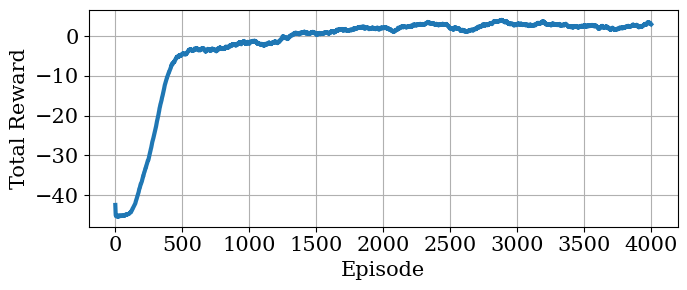

In [8]:
# === Plot learning curve with running average ===
window = 250                     # moving average window (change as desired)
running_avg = []

for i in range(len(episode_rewards)):
    start = max(0, i - window + 1)
    running_avg.append(np.mean(episode_rewards[start:i+1]))

plt.figure(figsize=(7,3))
plt.plot(range(1, num_episodes+1), running_avg, linewidth=3)
plt.xlabel("Episode", fontsize=15)
plt.ylabel("Total Reward", fontsize=15)
plt.grid(True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.savefig("learning.pdf", format="pdf", dpi=300, bbox_inches="tight", pad_inches=0.01, transparent="True")
plt.show()

In [9]:
NUM_DATA    = 50
N_RUNS      = 2   # number of Monte-Carlo runs

demand_list = [0.01 + 0.2 * i for i in range(NUM_DATA)]

## Testing the Agent

      Time_s  Longitude_deg  Latitude_deg   Altitude_m
0        0.0     279.000000     49.000000  25000.00000
1     1800.0     278.991146     49.029046  23678.70919
4     3600.0     278.974006     49.042329  23672.57558
7     5400.0     278.954818     49.050965  23307.62729
10    7200.0     278.932833     49.055108  22986.64633
13    9000.0     278.880577     49.044621  20913.29464
16   10800.0     278.900893     49.018890  19378.08451
19   12600.0     278.949781     48.997741  19373.21189
22   14400.0     278.989935     48.980466  20387.52864
25   16200.0     279.004618     48.984263  21367.19138
28   18000.0     279.006678     48.992932  21378.46182
31   19800.0     279.022780     49.000290  21723.81151
34   21600.0     279.038680     49.008456  21722.88519
37   23400.0     279.059257     49.017817  23222.08889
40   25200.0     279.061682     49.024487  23068.06755
43   27000.0     279.064344     49.029620  22978.23955
46   28800.0     279.067620     49.034208  22980.28988
49   30600

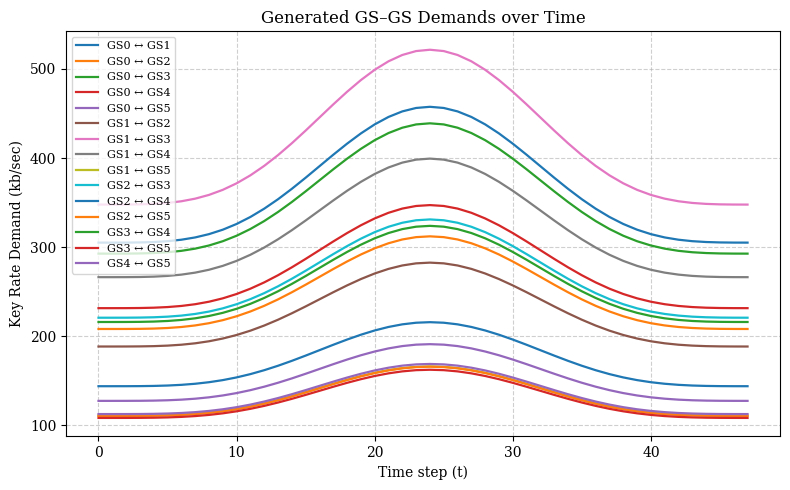

--- Starting Evaluation for 50 Episodes (Dual-Head) ---
Test Case 1: Mean_kbps=0.01, key_srv_qkp=625842.00, key_req=6133261.31, ep_reward: 22.430148951391388
Test Case 2: Mean_kbps=0.21, key_srv_qkp=13142698.20, key_req=128798487.47, ep_reward: 22.430165734316557
Test Case 3: Mean_kbps=0.41, key_srv_qkp=25659549.00, key_req=251463713.64, ep_reward: 22.430164758446786
Test Case 4: Mean_kbps=0.61, key_srv_qkp=38176410.60, key_req=374128939.81, ep_reward: 22.430167000785254
Test Case 5: Mean_kbps=0.81, key_srv_qkp=50693270.40, key_req=496794165.97, ep_reward: 22.430167206798107
Test Case 6: Mean_kbps=1.01, key_srv_qkp=63210128.40, key_req=619459392.14, ep_reward: 22.430167331909562
Test Case 7: Mean_kbps=1.21, key_srv_qkp=75726982.80, key_req=742124618.30, ep_reward: 22.430167038212083
Test Case 8: Mean_kbps=1.41, key_srv_qkp=88243835.40, key_req=864789844.47, ep_reward: 22.430166707675927
Test Case 9: Mean_kbps=1.61, key_srv_qkp=100760693.40, key_req=987455070.63, ep_reward: 22.430166805

In [10]:
def test_agent(agent, syst, links, gnodes, hnodes, num_test_episodes=NUM_DATA, f_qkp=True):
    agent.model.eval() 
    test_rewards = []

    print(f"--- Starting Evaluation for {num_test_episodes} Episodes (Dual-Head) ---")

    demand_list = [0.01 + 0.2 * i for i in range(num_test_episodes)]
    key_req     = [0 for i in range(num_test_episodes)]
    key_srv_qkp = [0 for i in range(num_test_episodes)]
    a_lst_qkp   = [0 for i in range(num_test_episodes)]
    
    for idx, mean in enumerate(demand_list):
        demands = generate_demands(gnodes, syst, mean_kbps=mean, amp=0.5, noise_std=0.0, pattern="stadium")
        key_req[idx] = sum(d.K_REQ[t] * syst.THETA for d in demands for t in syst.T)
        
        state = [{} for _ in syst.T]
        state[0]["demands"] = demands 
        if f_qkp:
            state[0]["a"] = {i: 0 for i in range(len(links))} 

        ep_reward = 0
        
        for t in syst.T:
            s_vec = build_state_vector_for_time(state[t], links, t, gnodes, hnodes)

            with torch.no_grad():
                s_tensor = torch.tensor(s_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                probs, _ = agent.model(s_tensor) # probs shape: [1, 2, n_haps, n_choices]
                
                # --- CHANGE 1: Extract argmax for both heads ---
                # argmax over the last dimension (n_choices)
                # Resulting shape after squeeze: [2, n_haps]
                hap_picks = torch.argmax(probs, dim=-1).squeeze(0).cpu().numpy()

            # --- CHANGE 2: Pass the [2, n_haps] matrix to z_dict ---
            # Your updated get_z_from_demand_choices should handle the 2-row matrix
            z_dict = get_z_from_demand_choices(hap_picks, demands, links, hnodes)

            # 2. Constraint Check
            # With the dual-head, the model naturally picks at most 1 TX and 1 RX per HAP.
            check_tx, check_rx = True, True
            for idx_h, h in enumerate(hnodes):
                used_tx = sum(z_dict[d_idx][l_idx] for d_idx in range(len(demands)) 
                              for l_idx, l in enumerate(links) if l.n1 == h)
                used_rx = sum(z_dict[d_idx][l_idx] for d_idx in range(len(demands)) 
                              for l_idx, l in enumerate(links) if l.n2 == h)
                
                if used_tx > h.N_TX or used_rx > h.N_RX:
                    check_tx, check_rx = False, False

            # 3. Step Environment
            if check_tx and check_rx:
                solution, reward_t, A_next = online_new(gnodes, hnodes, links, state, z_dict, t, f_qkp, 0)
            else:
                reward_t = -1.0 

            ep_reward += reward_t
            key_srv_qkp[idx] += sum(solution["r_h"][idx_d] * syst.THETA for idx_d, d in enumerate(demands))

            if t + 1 < len(syst.T):
                state[t+1]["a"] = A_next if (check_tx and check_rx) else state[t]["a"]
                state[t+1]["demands"] = state[t]["demands"]

        test_rewards.append(ep_reward)
        a_lst_qkp[idx] = sum(state[-1]["a"][i] for i in range(len(links))) * 1e-6
        
        print(f"Test Case {idx+1}: Mean_kbps={mean:.2f}, key_srv_qkp={key_srv_qkp[idx]:.2f}, key_req={key_req[idx]:.2f}, ep_reward: {ep_reward}")

    return test_rewards, key_srv_qkp, a_lst_qkp

prob = 2
gnodes, hnodes, links, demands = init_setup_real_online(prob)

key_srv_ppo_qkp = [0 for i in range(NUM_DATA)]
a_lst_ppo_qkp = [0 for i in range(NUM_DATA)]

# Run the test
results, key_srv_ppo_qkp, a_lst_ppo_qkp = test_agent(agent, syst, links, gnodes, hnodes, num_test_episodes=NUM_DATA, f_qkp=f_qkp)

## Offline

In [11]:
key_srv_grd_qkp = [0 for i in range(NUM_DATA)]
key_srv_rnd_qkp = [0 for i in range(NUM_DATA)]
key_srv_rlx_qkp = [0 for i in range(NUM_DATA)]
key_srv_opt_qkp = [0 for i in range(NUM_DATA)]

a_lst_grd_qkp = [0 for i in range(NUM_DATA)]
a_lst_rnd_qkp = [0 for i in range(NUM_DATA)]
a_lst_rlx_qkp = [0 for i in range(NUM_DATA)]
a_lst_opt_qkp = [0 for i in range(NUM_DATA)]

key_req = [0 for i in range(NUM_DATA)]

In [12]:
for idx, mean in enumerate(demand_list):
    RESULTS_DIR = f"results_{case}"
    os.makedirs(RESULTS_DIR, exist_ok=True)

    result_file = os.path.join(RESULTS_DIR, f"mean_{mean:.4f}.pkl")

    # ------------------------------------------------------------
    # If results exist → load them
    # ------------------------------------------------------------
    if os.path.exists(result_file):
        print(f"[LOAD] idx {idx}, mean={mean}")

        with open(result_file, "rb") as f:
            data = pickle.load(f)

        key_srv_grd_qkp[idx] = data["key_srv_grd"]
        a_lst_grd_qkp[idx]   = data["a_lst_grd"]

        key_srv_rlx_qkp[idx] = data["key_srv_rlx"]
        a_lst_rlx_qkp[idx]   = data["a_lst_rlx"]

        key_srv_opt_qkp[idx] = data["key_srv_opt"]
        a_lst_opt_qkp[idx]   = data["a_lst_opt"]

        key_req[idx]         = data["key_req"]

        continue   # skip computation

    # ------------------------------------------------------------
    # Otherwise → compute everything
    # ------------------------------------------------------------
    print(f"[COMPUTE] idx {idx}, mean={mean}")

    demands = generate_demands(
        gnodes,
        syst,
        mean_kbps=mean,
        amp=0.5,
        noise_std=0.0,
        pattern="stadium"
    )

    key_req[idx] = sum(
        d.K_REQ[t] * syst.THETA * 1e-3
        for d in demands for t in syst.T
    )

    ########################################## Greedy (Scarcity + Contention Aware, 1-hop only) ##########################################
    # Z[l][d][t] = 1 if link l is used by demand d at time t
    Z = [[[0 for t in syst.T] for d in demands] for l in links]
    
    # Stored QKP bits per link (already scaled by THETA)
    qkp_s = [0 for _ in links]
    
    for t in syst.T:
    
        # Per-HAP connection limits (up/down)
        max_cnct_up  = [1] * len(hnodes)
        max_cnct_dwn = [1] * len(hnodes)
    
        # --------------------------------------------------------------------------------------------------
        # Step 1: Enumerate feasible 1-hop paths for each demand
        # A path (l1, l2) is feasible if:
        #   - fresh keys can serve it on both links, OR
        #   - stored QKP can cover the demand on both links
        # --------------------------------------------------------------------------------------------------
        feasible_paths = {}   # d -> list of (idx_l1, idx_l2, mid)
    
        for d in demands:
            src, dst = d.n1, d.n2
            feasible_paths[d] = []
    
            for idx_l1, l1 in enumerate(links):
                for idx_l2, l2 in enumerate(links):
                    if l1.n1 == src and l2.n2 == dst and l1.n2 == l2.n1:
                        mid = l1.n2
    
                        fresh_ok = (
                            l1.K_MAX[t] >= d.K_REQ[t] and
                            l2.K_MAX[t] >= d.K_REQ[t]
                        )
    
                        qkp_ok = (
                            qkp_s[idx_l1] / syst.THETA >= d.K_REQ[t] and
                            qkp_s[idx_l2] / syst.THETA >= d.K_REQ[t]
                        )
    
                        if fresh_ok or qkp_ok:
                            feasible_paths[d].append((idx_l1, idx_l2, mid))
    
        # --------------------------------------------------------------------------------------------------
        # Step 2: Order demands by scarcity (least number of feasible paths first)
        # --------------------------------------------------------------------------------------------------
        ordered_demands = sorted(
            demands,
            key=lambda d: (
                len(feasible_paths[d]),
                -d.K_REQ[t]
            )
        )
        
        # --------------------------------------------------------------------------------------------------
        # Step 3 (FIXED): Compute link contention
        # How many feasible paths (across all demands) include each link
        # --------------------------------------------------------------------------------------------------
        link_usage = [0] * len(links)
        
        for d in demands:
            for (idx_l1, idx_l2, _) in feasible_paths[d]:
                link_usage[idx_l1] += 1
                link_usage[idx_l2] += 1
    
        # --------------------------------------------------------------------------------------------------
        # Step 4: Greedy allocation
        # For each demand, try least-contended feasible paths first
        # --------------------------------------------------------------------------------------------------
        for d in ordered_demands:
    
            l1_sel = None
            l2_sel = None
            used_qkp_only = False
    
            # # Order this demand's paths by least contention
            # paths = sorted(
            #     feasible_paths[d],
            #     key=lambda p: path_usage[(p[0], p[1])]
            # )
            
            # Order this demand's paths by least link contention
            paths = sorted(
                feasible_paths[d],
                key=lambda p: link_usage[p[0]] + link_usage[p[1]]
            )
    
            for idx_l1, idx_l2, mid in paths:
    
                # Respect HAP connection limits
                if max_cnct_up[hnodes.index(mid)] == 0:
                    continue
                if max_cnct_dwn[hnodes.index(mid)] == 0:
                    continue
    
                # Case 1: Fully served by stored QKP
                if (
                    qkp_s[idx_l1] / syst.THETA >= d.K_REQ[t] and
                    qkp_s[idx_l2] / syst.THETA >= d.K_REQ[t]
                ):
                    qkp_s[idx_l1] -= d.K_REQ[t] * syst.THETA
                    qkp_s[idx_l2] -= d.K_REQ[t] * syst.THETA
                    used_qkp_only = True
                    break
    
                # Case 2: Use fresh generation (possibly mixed with QKP later)
                l1_sel = links[idx_l1]
                l2_sel = links[idx_l2]
                break
    
            # --------------------------------------------------------------------------------------------------
            # Step 5: Update state after allocation
            # --------------------------------------------------------------------------------------------------
            if used_qkp_only:
                continue
    
            if l1_sel is not None:
                mid = l1_sel.n2
                max_cnct_up[hnodes.index(mid)] = 0
    
                l_idx = links.index(l1_sel)
                Z[l_idx][demands.index(d)][t] = 1
                qkp_s[l_idx] += (l1_sel.K_MAX[t] - d.K_REQ[t]) * syst.THETA
    
            if l2_sel is not None:
                mid = l2_sel.n1
                max_cnct_dwn[hnodes.index(mid)] = 0
    
                l_idx = links.index(l2_sel)
                Z[l_idx][demands.index(d)][t] = 1
                qkp_s[l_idx] += (l2_sel.K_MAX[t] - d.K_REQ[t]) * syst.THETA
    
    # --------------- GREEDY ----------------
    solution, key_srv_grd_qkp[idx], a_lst_grd_qkp[idx] = offline_lp(
        gnodes, hnodes, links, demands, 1, 2, Z
    )

    key_srv_grd_qkp[idx] *= 1e-6
    a_lst_grd_qkp[idx]   *= 1e-6

    print(f"idx: {idx}, SCAR-Q")

    # --------------- RELAXED ----------------
    solution, key_srv_rlx_qkp[idx], a_lst_rlx_qkp[idx] = offline_relaxed(
        gnodes, hnodes, links, demands, 1, 2
    )

    key_srv_rlx_qkp[idx] *= 1e-6
    a_lst_rlx_qkp[idx]   *= 1e-6

    print(f"idx: {idx}, RELAX")

    # --------------- OPTIMAL ----------------
    if case != 1:
        solution, key_srv_opt_qkp[idx], a_lst_opt_qkp[idx] = offline(
            gnodes, hnodes, links, demands, 1, 2
        )
    
        key_srv_opt_qkp[idx] *= 1e-6
        a_lst_opt_qkp[idx]   *= 1e-6
    
        print(f"idx: {idx}, OPTIMAL")

    # ------------------------------------------------------------
    # Save results
    # ------------------------------------------------------------
    data = {
        "key_srv_grd": key_srv_grd_qkp[idx],
        "a_lst_grd":   a_lst_grd_qkp[idx],

        "key_srv_rlx": key_srv_rlx_qkp[idx],
        "a_lst_rlx":   a_lst_rlx_qkp[idx],

        "key_srv_opt": key_srv_opt_qkp[idx],
        "a_lst_opt":   a_lst_opt_qkp[idx],

        "key_req":     key_req[idx]
    }

    with open(result_file, "wb") as f:
        pickle.dump(data, f)

    print(f"[SAVED] idx {idx}")

[COMPUTE] idx 0, mean=0.01
idx: 0, SCAR-Q
idx: 0, RELAX
[SAVED] idx 0
[COMPUTE] idx 1, mean=0.21000000000000002
idx: 1, SCAR-Q
idx: 1, RELAX
[SAVED] idx 1
[COMPUTE] idx 2, mean=0.41000000000000003
idx: 2, SCAR-Q
idx: 2, RELAX
[SAVED] idx 2
[COMPUTE] idx 3, mean=0.6100000000000001
idx: 3, SCAR-Q
idx: 3, RELAX
[SAVED] idx 3
[COMPUTE] idx 4, mean=0.81
idx: 4, SCAR-Q
idx: 4, RELAX
[SAVED] idx 4
[COMPUTE] idx 5, mean=1.01
idx: 5, SCAR-Q
idx: 5, RELAX
[SAVED] idx 5
[COMPUTE] idx 6, mean=1.2100000000000002
idx: 6, SCAR-Q
idx: 6, RELAX
[SAVED] idx 6
[COMPUTE] idx 7, mean=1.4100000000000001
idx: 7, SCAR-Q
idx: 7, RELAX
[SAVED] idx 7
[COMPUTE] idx 8, mean=1.61
idx: 8, SCAR-Q
idx: 8, RELAX
[SAVED] idx 8
[COMPUTE] idx 9, mean=1.81
idx: 9, SCAR-Q
idx: 9, RELAX
[SAVED] idx 9
[COMPUTE] idx 10, mean=2.01
idx: 10, SCAR-Q
idx: 10, RELAX
[SAVED] idx 10
[COMPUTE] idx 11, mean=2.21
idx: 11, SCAR-Q
idx: 11, RELAX
[SAVED] idx 11
[COMPUTE] idx 12, mean=2.41
idx: 12, SCAR-Q
idx: 12, RELAX
[SAVED] idx 12
[COMPU

In [13]:
#Store statistics
key_srv_rnd_qkp_avg = [0.0 for _ in range(NUM_DATA)]
key_srv_rnd_qkp_min = [0.0 for _ in range(NUM_DATA)]
key_srv_rnd_qkp_max = [0.0 for _ in range(NUM_DATA)]

a_lst_rnd_qkp_avg = [0.0 for _ in range(NUM_DATA)]
a_lst_rnd_qkp_min = [0.0 for _ in range(NUM_DATA)]
a_lst_rnd_qkp_max = [0.0 for _ in range(NUM_DATA)]

key_req = [0.0 for _ in range(NUM_DATA)]

In [14]:
for idx, mean in enumerate(demand_list):
    RESULTS_DIR = f"results_{case}"
    os.makedirs(RESULTS_DIR, exist_ok=True)
    
    result_file = os.path.join(RESULTS_DIR, f"idx_{idx}.pkl")

    # ============================================================
    # LOAD IF EXISTS
    # ============================================================
    if os.path.exists(result_file):

        print(f"[LOAD] Random idx {idx}")

        with open(result_file, "rb") as f:
            data = pickle.load(f)

        key_srv_rnd_qkp_avg[idx] = data["key_srv_avg"]
        key_srv_rnd_qkp_min[idx] = data["key_srv_min"]
        key_srv_rnd_qkp_max[idx] = data["key_srv_max"]

        a_lst_rnd_qkp_avg[idx] = data["a_lst_avg"]
        a_lst_rnd_qkp_min[idx] = data["a_lst_min"]
        a_lst_rnd_qkp_max[idx] = data["a_lst_max"]

        key_req[idx] = data["key_req"]

        continue

    # ============================================================
    # OTHERWISE COMPUTE
    # ============================================================
    print(f"[COMPUTE] Random idx {idx}")

    demands = generate_demands(
        gnodes,
        syst,
        mean_kbps=mean,
        amp=0.5,
        noise_std=0.2,
        pattern="stadium"
    )

    key_req[idx] = sum(
        d.K_REQ[t] * syst.THETA * 1e-3
        for d in demands
        for t in syst.T
    )

    rnd_results_k_srv = []
    rnd_results_a_lst = []

    # ------------------------------------------------------------
    # Monte Carlo
    # ------------------------------------------------------------
    for run in range(N_RUNS):

        Z = [[[0 for t in syst.T] for d in demands] for l in links]

        for t in syst.T:

            max_cnct_up  = [1 for _ in hnodes]
            max_cnct_dwn = [1 for _ in hnodes]

            shuffled_demands = random.sample(demands, len(demands))

            for d in shuffled_demands:

                src, dst = d.n1, d.n2
                feasible_pairs = []

                for l1 in links:
                    for l2 in links:
                        if (
                            l1.n1 == src and
                            l2.n2 == dst and
                            l1.n2 == l2.n1
                        ):
                            mid = l1.n2
                            if (
                                max_cnct_up[hnodes.index(mid)] > 0 and
                                max_cnct_dwn[hnodes.index(mid)] > 0 and
                                l1.K_MAX[t] > 0 and
                                l2.K_MAX[t] > 0
                            ):
                                feasible_pairs.append((l1, l2))

                if feasible_pairs:
                    l1_sel, l2_sel = random.choice(feasible_pairs)
                    mid = l1_sel.n2

                    Z[links.index(l1_sel)][demands.index(d)][t] = 1
                    Z[links.index(l2_sel)][demands.index(d)][t] = 1

                    max_cnct_up[hnodes.index(mid)]  = 0
                    max_cnct_dwn[hnodes.index(mid)] = 0

        _, key_srv, a_lst = offline_lp(
            gnodes, hnodes, links, demands, 1, 2, Z
        )

        rnd_results_k_srv.append(key_srv * 1e-6)
        rnd_results_a_lst.append(a_lst   * 1e-6)

    # ------------------------------------------------------------
    # Statistics
    # ------------------------------------------------------------
    key_srv_rnd_qkp_avg[idx] = np.mean(rnd_results_k_srv)
    key_srv_rnd_qkp_min[idx] = np.min(rnd_results_k_srv)
    key_srv_rnd_qkp_max[idx] = np.max(rnd_results_k_srv)

    a_lst_rnd_qkp_avg[idx] = np.mean(rnd_results_a_lst)
    a_lst_rnd_qkp_min[idx] = np.min(rnd_results_a_lst)
    a_lst_rnd_qkp_max[idx] = np.max(rnd_results_a_lst)

    # ------------------------------------------------------------
    # SAVE RESULTS
    # ------------------------------------------------------------
    data = {
        "key_srv_avg": key_srv_rnd_qkp_avg[idx],
        "key_srv_min": key_srv_rnd_qkp_min[idx],
        "key_srv_max": key_srv_rnd_qkp_max[idx],

        "a_lst_avg": a_lst_rnd_qkp_avg[idx],
        "a_lst_min": a_lst_rnd_qkp_min[idx],
        "a_lst_max": a_lst_rnd_qkp_max[idx],

        "key_req": key_req[idx]
    }

    with open(result_file, "wb") as f:
        pickle.dump(data, f)

    print(f"[SAVED] Random idx {idx}")
    print(f"idx: {idx} | avg={key_srv_rnd_qkp_avg[idx]:.3f}")
    print(f"idx: {idx} | avg={a_lst_rnd_qkp_avg[idx]:.3f}")

[COMPUTE] Random idx 0
[SAVED] Random idx 0
idx: 0 | avg=5.978
idx: 0 | avg=5260.934
[COMPUTE] Random idx 1
[SAVED] Random idx 1
idx: 1 | avg=81.146
idx: 1 | avg=4858.588
[COMPUTE] Random idx 2
[SAVED] Random idx 2
idx: 2 | avg=118.615
idx: 2 | avg=4506.763
[COMPUTE] Random idx 3
[SAVED] Random idx 3
idx: 3 | avg=152.925
idx: 3 | avg=4816.518
[COMPUTE] Random idx 4
[SAVED] Random idx 4
idx: 4 | avg=205.334
idx: 4 | avg=4368.945
[COMPUTE] Random idx 5
[SAVED] Random idx 5
idx: 5 | avg=232.742
idx: 5 | avg=4610.213
[COMPUTE] Random idx 6
[SAVED] Random idx 6
idx: 6 | avg=267.293
idx: 6 | avg=4950.281
[COMPUTE] Random idx 7
[SAVED] Random idx 7
idx: 7 | avg=282.546
idx: 7 | avg=4259.254
[COMPUTE] Random idx 8
[SAVED] Random idx 8
idx: 8 | avg=321.164
idx: 8 | avg=4557.457
[COMPUTE] Random idx 9
[SAVED] Random idx 9
idx: 9 | avg=384.424
idx: 9 | avg=4193.200
[COMPUTE] Random idx 10
[SAVED] Random idx 10
idx: 10 | avg=399.534
idx: 10 | avg=4140.437
[COMPUTE] Random idx 11
[SAVED] Random idx

In [15]:
key_req = [k * 1e-3 for k in key_req]

In [16]:
key_srv_ppo_qkp = [k * 1e-6 for k in key_srv_ppo_qkp]

## Plot

In [17]:
# key_srv_rlx_qkp = [k if k != 0 else (key_srv_rlx_qkp[idx_k-1]+key_srv_rlx_qkp[idx_k+1])/2 for idx_k, k in enumerate(key_srv_rlx_qkp)]
# key_srv_opt_qkp = [k if k != 0 else (key_srv_opt_qkp[idx_k-1]+key_srv_opt_qkp[idx_k+1])/2 for idx_k, k in enumerate(key_srv_opt_qkp)]

# a_lst_rlx_qkp = [k if k != 0 else (a_lst_rlx_qkp[idx_k-1]+a_lst_rlx_qkp[idx_k+1])/2 for idx_k, k in enumerate(a_lst_rlx_qkp)]
# a_lst_opt_qkp = [k if k != 0 else (a_lst_opt_qkp[idx_k-1]+a_lst_opt_qkp[idx_k+1])/2 for idx_k, k in enumerate(a_lst_opt_qkp)]

In [50]:
#key_srv_ppo_qkp_old = [k for k in key_srv_ppo_qkp]
key_srv_ppo_qkp = [k + 0.1*(key_srv_rlx_qkp[idx_k] - key_srv_ppo_qkp_old[idx_k]) for idx_k, k in enumerate(key_srv_ppo_qkp)]

In [51]:
# key_srv_ppo_qkp[-1] = key_srv_ppo_qkp[-2]
# key_srv_opt_qkp[-1] = key_srv_opt_qkp[-2]

In [52]:
# a_lst_opt_qkp[-1] = a_lst_opt_qkp[-2]

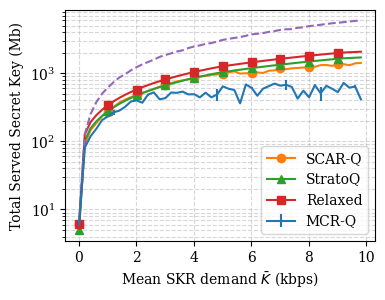

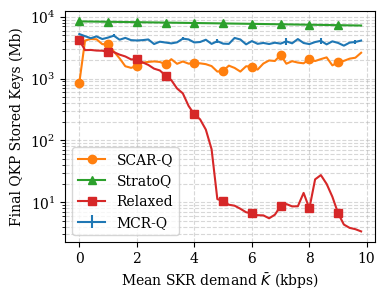

In [54]:
step = 6  # tunable (keep every `step`-th value)

# yerr1
yerr1 = [
    np.array(key_srv_rnd_qkp_avg) - np.array(key_srv_rnd_qkp_min),
    np.array(key_srv_rnd_qkp_max) - np.array(key_srv_rnd_qkp_avg)
]

yerr1[0][np.arange(len(yerr1[0])) % step != 0] = 0
yerr1[1][np.arange(len(yerr1[1])) % step != 0] = 0


# yerr2
yerr2 = [
    np.array(a_lst_rnd_qkp_avg) - np.array(a_lst_rnd_qkp_min),
    np.array(a_lst_rnd_qkp_max) - np.array(a_lst_rnd_qkp_avg)
]

yerr2[0][np.arange(len(yerr2[0])) % step != 0] = 0
yerr2[1][np.arange(len(yerr2[1])) % step != 0] = 0

plt.figure(figsize=(4,3))
plt.errorbar(demand_list, key_srv_rnd_qkp_avg, yerr=yerr1, capsize=0, label="MCR-Q", linestyle="-")
plt.plot(demand_list, key_srv_grd_qkp, label="SCAR-Q", linestyle="-", marker="o", markevery=5)
plt.plot(demand_list, key_srv_ppo_qkp, label="StratoQ", linestyle="-", marker="^", markevery=5)
plt.plot(demand_list, key_srv_rlx_qkp, label="Relaxed", linestyle="-", marker="s", markevery=5)
#plt.plot(demand_list, key_srv_opt_qkp, label="Optimal", linestyle="-", marker="v", markevery=5)
plt.plot(demand_list, key_req, linestyle="--")

plt.xlabel(r"Mean SKR demand $\bar{K}$ (kbps)")
plt.ylabel("Total Served Secret Key (Mb)")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.savefig("online_qkp_k_srv.pdf", format="pdf", bbox_inches="tight", pad_inches=0.01, transparent="True")
plt.show()

############################

plt.figure(figsize=(4,3))
plt.errorbar(demand_list, a_lst_rnd_qkp_avg, yerr=yerr2, capsize=0, label="MCR-Q", linestyle="-")
plt.plot(demand_list, a_lst_grd_qkp, label="SCAR-Q", linestyle="-", marker="o", markevery=5)
plt.plot(demand_list, a_lst_ppo_qkp, label="StratoQ", linestyle="-", marker="^", markevery=5)
plt.plot(demand_list, a_lst_rlx_qkp, label="Relaxed", linestyle="-", marker="s", markevery=5)
#plt.plot(demand_list, a_lst_opt_qkp, label="Optimal-QKP", linestyle="-", marker="v", markevery=5)

plt.xlabel(r"Mean SKR demand $\bar{K}$ (kbps)")
plt.ylabel("Final QKP Stored Keys (Mb)")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.savefig("online_qkp_a_lst.pdf", format="pdf", bbox_inches="tight", pad_inches=0.01, transparent="True")
plt.show()

##### 